# Importing Libraries

In [1]:
import gc
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import warnings
import joblib
warnings.filterwarnings('ignore')
print("Libraries Imported")

2026-04-13 16:39:01.091483: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776098341.324325      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776098341.389116      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776098341.904678      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776098341.904718      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776098341.904720      23 computation_placer.cc:177] computation placer alr

Libraries Imported


# Defining Functions

In [2]:
def data_generator(X, y, batch_size=32):
    num_samples = X.shape[0]
    
    if isinstance(y, pd.Series):
        y = y.values
        
    while True:
        indices = np.random.permutation(num_samples)
        
        for start in range(0, num_samples, batch_size):
            end = min(start + batch_size, num_samples)
            batch_idx = indices[start:end]
            
            X_batch = X[batch_idx].toarray()
            y_batch = y[batch_idx]
            
            yield X_batch, y_batch

class CustomMetricsPrinter(tf.keras.callbacks.Callback):
    def __init__(self, config):
        super().__init__()
        self.config = config

    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        loss = logs.get('loss', 0.0)
        acc = logs.get('accuracy', 0.0)
        val_loss = logs.get('val_loss', 0.0)
        val_acc = logs.get('val_accuracy', 0.0)
        epochs = self.params['epochs']
        
        print(f"Config: {self.config}, Epoch: {epoch + 1}/{epochs}")
        print(f"train_accuracy: {acc:.4f}, train_loss: {loss:.4f}; val_accuracy: {val_acc:.4f}, val_loss: {val_loss:.4f}")
print("Functions Defined")

Functions Defined


# Reading data

In [3]:
print("Loading data...")

account = 'jeeshanalam'
dataset = 'original'

train_df  = pd.read_parquet(f'/kaggle/input/datasets/{account}/{dataset}/train.parquet')
val_df    = pd.read_parquet(f'/kaggle/input/datasets/{account}/{dataset}/val.parquet')
test_df   = pd.read_parquet(f'/kaggle/input/datasets/{account}/{dataset}/test.parquet')


print(f"{dataset} Data Loaded\n")
print(f"{train_df.shape[0]} training samples")
print(f"{val_df.shape[0]}  validation samples")
print(f"{test_df.shape[0]}  testing samples\n")

text_col = 'text'
label_col = 'generated_by'

Loading data...
original Data Loaded

796800 training samples
99600  validation samples
99600  testing samples



# Splitting Data

In [4]:
X_train_raw,  y_train  = train_df[text_col],  train_df[label_col]
X_val_raw,    y_val    = val_df[text_col],    val_df[label_col]
X_test_raw,   y_test   = test_df[text_col],   test_df[label_col]

# Encoding Labels

In [5]:
print("Encoding labels to integers...")

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_val = label_encoder.transform(y_val)
y_test = label_encoder.transform(y_test)

classes = label_encoder.classes_
num_classes = len(classes)
print(f"Detected {num_classes} unique classes:", *classes, sep = "\n\t")
print('Labels Encoded Successfully')

Encoding labels to integers...
Detected 12 unique classes:
	chatgpt
	cohere
	cohere-chat
	gpt2
	gpt3
	gpt4
	human
	llama-chat
	mistral
	mistral-chat
	mpt
	mpt-chat
Labels Encoded Successfully


# TF-IDF Tokenization

In [6]:
print("Applying TF-IDF...")

tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 3))

X_train_tfidf = tfidf.fit_transform(X_train_raw)
X_val_tfidf   = tfidf.transform(X_val_raw)
X_test_tfidf  = tfidf.transform(X_test_raw)

print("TF-IDF Applied\n")
print(f"TF-IDF training matrix shape   : {X_train_tfidf.shape}")
print(f"TF-IDF validation matrix shape : {X_val_tfidf.shape}")
print(f"TF-IDF testing matrix shape    : {X_test_tfidf.shape}")

Applying TF-IDF...
TF-IDF Applied

TF-IDF training matrix shape   : (796800, 50000)
TF-IDF validation matrix shape : (99600, 50000)
TF-IDF testing matrix shape    : (99600, 50000)


# Freeing space in RAM

In [7]:
X_train_final  = X_train_tfidf
X_val_final    = X_val_tfidf
X_test_final   = X_test_tfidf

del X_train_tfidf, X_val_tfidf, X_test_tfidf
del X_train_raw, X_val_raw, X_test_raw
del train_df, val_df, test_df
gc.collect()
print("Memory Cleared")

Memory Cleared


# Neural Network Application

In [8]:
print("Training and tuning Neural Networks...")

config = (1024, 512)

input_dim = X_train_final.shape[1]

neurons_l1, neurons_l2 = config
print(f"\nTraining config: Layer 1 = {neurons_l1} neurons, Layer 2 = {neurons_l2} neurons")

model = Sequential([
    Input(shape=(input_dim,)), 
        
    Dense(neurons_l1, activation='relu'),
    BatchNormalization(), 
    Dropout(0.5),         
        
    Dense(neurons_l2, activation='relu'),
    BatchNormalization(), 
    Dropout(0.3),
        
    Dense(num_classes, activation='softmax') 
])

custom_optimizer = Adam(learning_rate=0.0001)
model.compile(optimizer=custom_optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        
batch_size = 32

steps_per_epoch = int(np.ceil(X_train_final.shape[0] / batch_size))
val_steps = int(np.ceil(X_val_final.shape[0] / batch_size))
    
epochs_to_run = 20

best_epoch_restorer = EarlyStopping(
    monitor='val_accuracy', 
    mode='max', 
    patience=epochs_to_run, 
    restore_best_weights=True
)

model.fit(
    data_generator(X_train_final, y_train, batch_size),
    validation_data=data_generator(X_val_final, y_val, batch_size),
    steps_per_epoch=steps_per_epoch,
    validation_steps=val_steps,
    epochs=epochs_to_run, 
    verbose=0, 
    callbacks=[CustomMetricsPrinter(config), best_epoch_restorer] 
)

val_loss, val_acc = model.evaluate(
    data_generator(X_val_final, y_val, batch_size), 
    steps=val_steps, 
    verbose=0 
)
print(f"Validation Loss: {val_loss:.4f} | Validation Accuracy: {val_acc:.4f}")

print(f"\n==========================================")
print(f"CONFIGURATION:")
print(f"Layer 1: {config[0]} neurons | Layer 2: {config[1]} neurons")
print(f"Best Validation Accuracy: {val_acc:.4f}")
print(f"Associated Validation Loss: {val_loss:.4f}")
print(f"==========================================\n")

Training and tuning Neural Networks...

Training config: Layer 1 = 1024 neurons, Layer 2 = 512 neurons


I0000 00:00:1776099363.309974      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776099363.316391      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
I0000 00:00:1776099367.112855      75 service.cc:152] XLA service 0x79647800c0a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776099367.112921      75 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1776099367.112929      75 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1776099367.560907      75 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776099370.123026      75 device_compiler.h:188] Compiled clust

Config: (1024, 512), Epoch: 1/20
train_accuracy: 0.5982, train_loss: 1.1748; val_accuracy: 0.7327, val_loss: 0.7671
Config: (1024, 512), Epoch: 2/20
train_accuracy: 0.7611, train_loss: 0.6943; val_accuracy: 0.7778, val_loss: 0.6413
Config: (1024, 512), Epoch: 3/20
train_accuracy: 0.8286, train_loss: 0.4977; val_accuracy: 0.7934, val_loss: 0.6094
Config: (1024, 512), Epoch: 4/20
train_accuracy: 0.8605, train_loss: 0.4021; val_accuracy: 0.7950, val_loss: 0.6300
Config: (1024, 512), Epoch: 5/20
train_accuracy: 0.8755, train_loss: 0.3572; val_accuracy: 0.7995, val_loss: 0.6409
Config: (1024, 512), Epoch: 6/20
train_accuracy: 0.8848, train_loss: 0.3306; val_accuracy: 0.7995, val_loss: 0.6639
Config: (1024, 512), Epoch: 7/20
train_accuracy: 0.8902, train_loss: 0.3131; val_accuracy: 0.8000, val_loss: 0.6760
Config: (1024, 512), Epoch: 8/20
train_accuracy: 0.8941, train_loss: 0.3018; val_accuracy: 0.8012, val_loss: 0.6877
Config: (1024, 512), Epoch: 9/20
train_accuracy: 0.8968, train_loss: 0.2

# Evaluate on Test Data

Evaluating the model on unseen Test Data...
3113/3113 ━━━━━━━━━━━━━━━━━━━━ 407s 131ms/step
Final Test Accuracy: 0.8030

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.86      0.89      8256
           1       0.83      0.79      0.81      8425
           2       0.86      0.76      0.81      8339
           3       0.83      0.77      0.80      8294
           4       0.87      0.83      0.85      8185
           5       0.92      0.87      0.89      8273
           6       0.88      0.85      0.86      8242
           7       0.91      0.85      0.88      8430
           8       0.42      0.78      0.54      8212
           9       0.85      0.76      0.80      8319
          10       0.85      0.75      0.80      8290
          11       0.88      0.76      0.82      8335

    accuracy                           0.80     99600
   macro avg       0.84      0.80      0.81     99600
weighted avg       0.84      0.80      0.81  

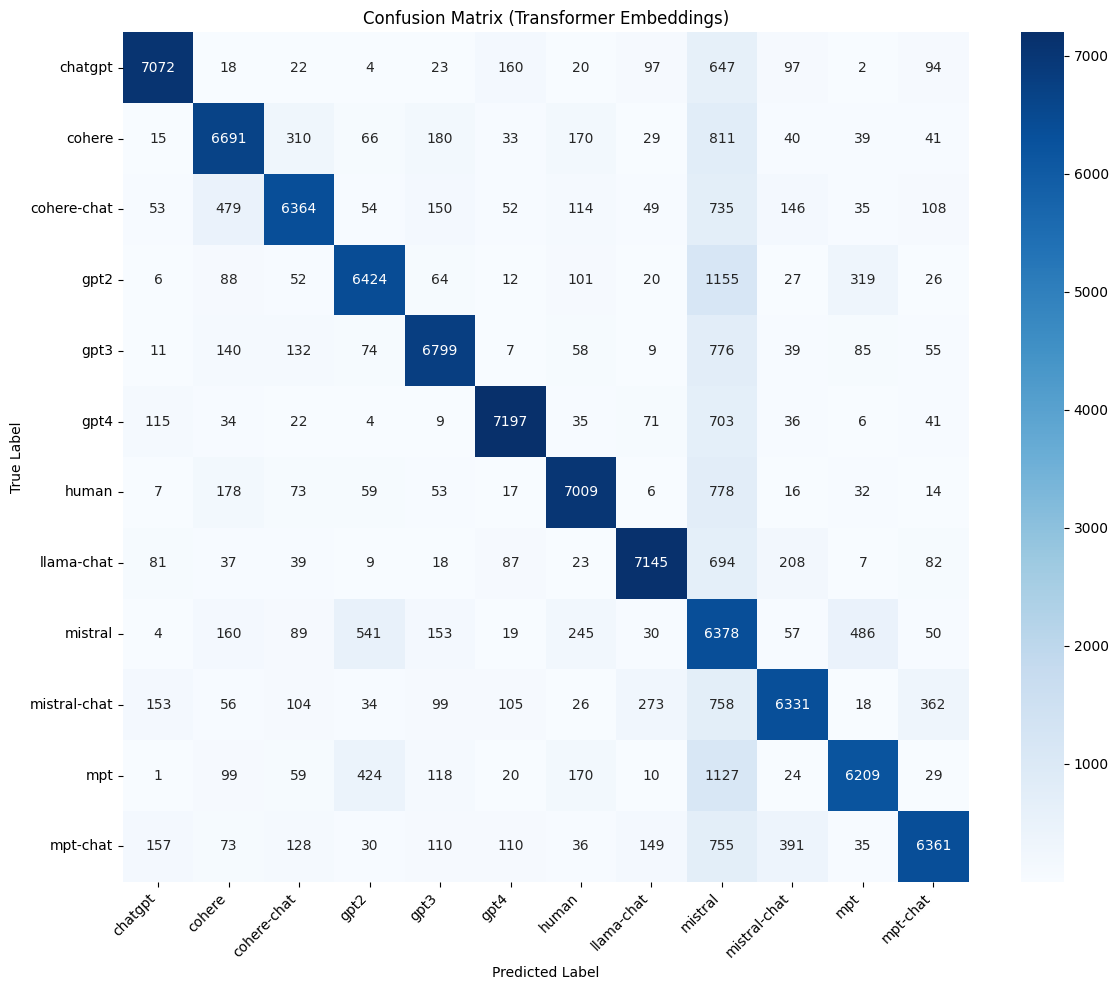

In [9]:
print("Evaluating the model on unseen Test Data...")

y_pred_probs = model.predict(X_test_final)
y_pred = np.argmax(y_pred_probs, axis=1)

test_acc = accuracy_score(y_test, y_pred)

print(f"{'='*40}\nFinal Test Accuracy: {test_acc:.4f}\n{'='*40}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)

plt.title('Confusion Matrix (Transformer Embeddings)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right') 
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Testing a custom text

In [10]:
print("Testing Custom String...")

custom_text = "You are correct. But I am a human. The model me will definitely missclassify me as a LLM. Execute the given codes to see for yourself." 
custom_tfidf = tfidf.transform([custom_text])
custom_dense = custom_tfidf.toarray()
probabilities = model.predict(custom_dense)[0] 
class_names = label_encoder.classes_
class_probs = list(zip(class_names, probabilities))
class_probs.sort(key=lambda x: x[1], reverse=True)

print(f"\nInput Text: \n'{custom_text}'\n")
print("="*50)
print(f"PREDICTED CLASS: {class_probs[0][0]} (Confidence: {class_probs[0][1]*100:.2f}%)")
print("="*50)
print("Confidence distribution across all classes:\n")

for class_name, prob in class_probs:
    print(f"{class_name.ljust(15)} : {prob*100:>7.4f}%")

Testing Custom String...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 640ms/step

Input Text: 
'You are correct. But I am a human. The model me will definitely missclassify me as a LLM. Execute the given codes to see for yourself.'

PREDICTED CLASS: mistral (Confidence: 49.63%)
Confidence distribution across all classes:

mistral         : 49.6308%
cohere          : 21.8790%
mpt             : 21.7268%
cohere-chat     :  4.3696%
gpt2            :  1.6427%
mpt-chat        :  0.2984%
gpt3            :  0.2300%
human           :  0.1261%
gpt4            :  0.0712%
chatgpt         :  0.0145%
mistral-chat    :  0.0101%
llama-chat      :  0.0010%
